In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="talk")
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "Notebook" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "Data" / "netflix_titles.csv"
VISUALS_DIR = PROJECT_ROOT / "visuals"
VISUALS_DIR.mkdir(exist_ok=True)

In [68]:
df = pd.read_csv(DATA_PATH)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


## Movies vs TV Shows
Netflix has significantly more movies than TV shows, showing that films dominate the platform's catalog.



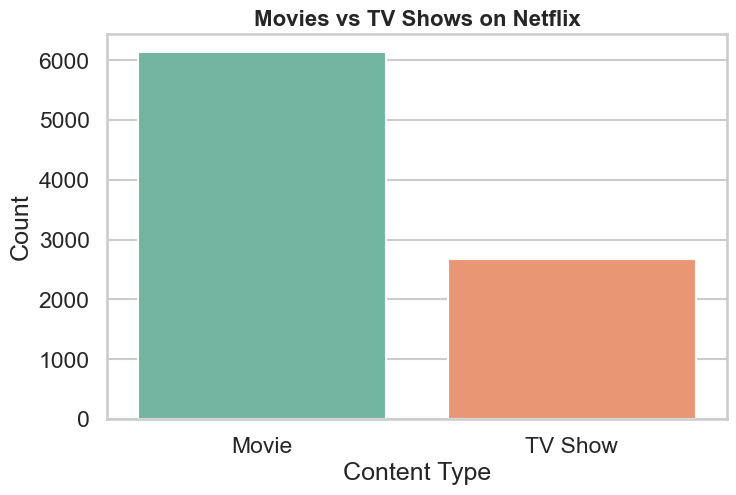

In [70]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x="type",
    hue="type",
    data=df,
    palette="Set2",
    legend=False
)

plt.title("Movies vs TV Shows on Netflix", fontsize=16, weight="bold")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.savefig(VISUALS_DIR / "movies_vs_tvshows.png", dpi=300)
plt.show()

## Top Countries
The United States contributes the highest number of titles, followed by India and the United Kingdom.

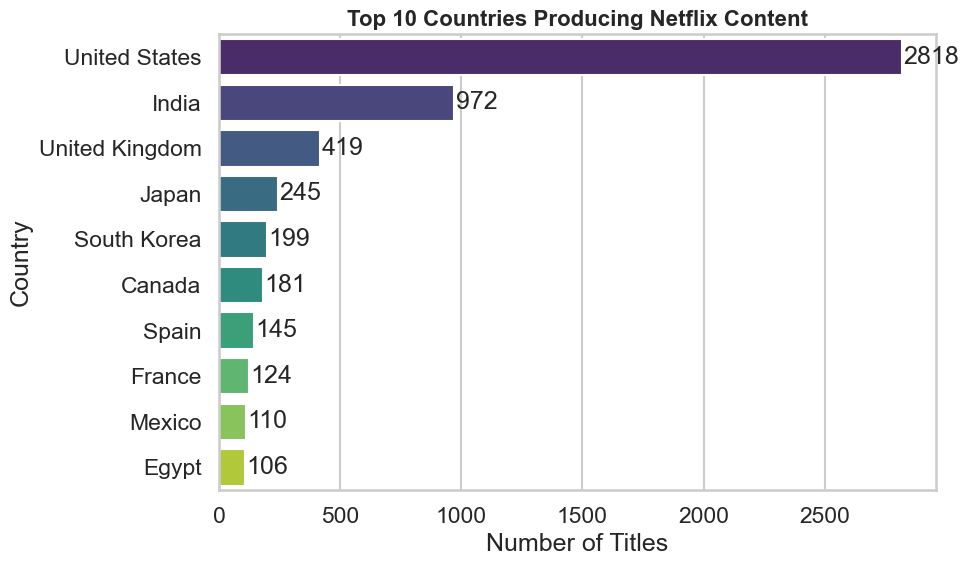

In [71]:
country_data = df.dropna(subset=["country"]).copy()
country_data["country"] = country_data["country"].str.split(", ")
country_exploded = country_data.explode("country")
top_countries = country_exploded["country"].value_counts().head(10)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Countries Producing Netflix Content", fontsize=16, weight="bold")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

for i, v in enumerate(top_countries.values):
    ax.text(v + 5, i, str(v), va='center')

plt.tight_layout()
plt.savefig(VISUALS_DIR / "top_countries.png", dpi=300)
plt.show()

## Content Growth
Netflix content additions grew rapidly after 2015, with the peak around 2019.

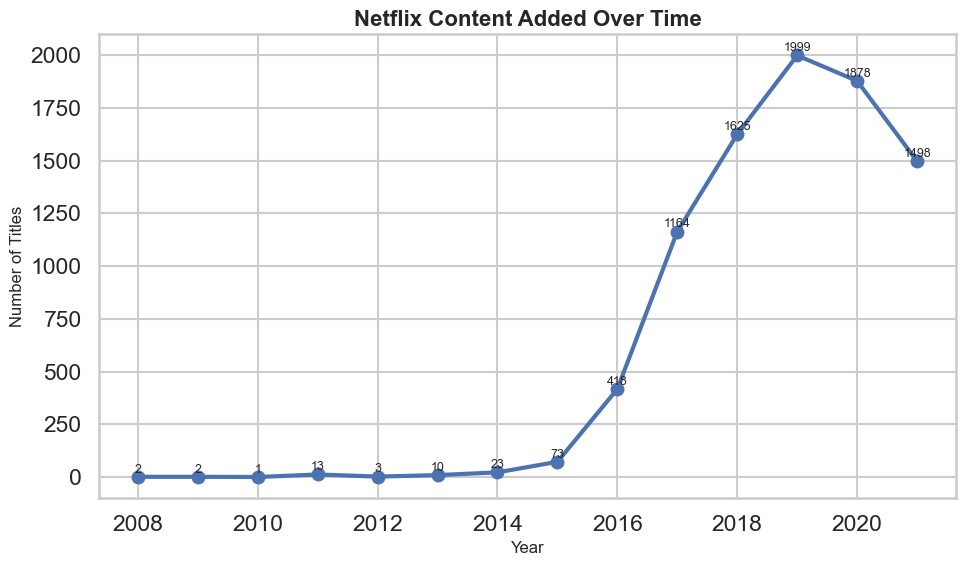

In [72]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year

year_counts = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.plot(year_counts.index, year_counts.values, marker="o", linewidth=3)

plt.title("Netflix Content Added Over Time", fontsize=16, weight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Titles", fontsize=12)

for x, y in zip(year_counts.index, year_counts.values):
    plt.text(x, y + 20, str(y), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(VISUALS_DIR / "content_growth.png", dpi=300, bbox_inches="tight")
plt.show()


## Top Genres
Some genres appear much more frequently than others, indicating strong viewer demand in a few major categories.

In [73]:
genre_data = df.dropna(subset=["listed_in"]).copy()

genre_data["listed_in"] = genre_data["listed_in"].str.split(", ")

genre_exploded = genre_data.explode("listed_in")

top_genres = genre_exploded["listed_in"].value_counts().head(10)

top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

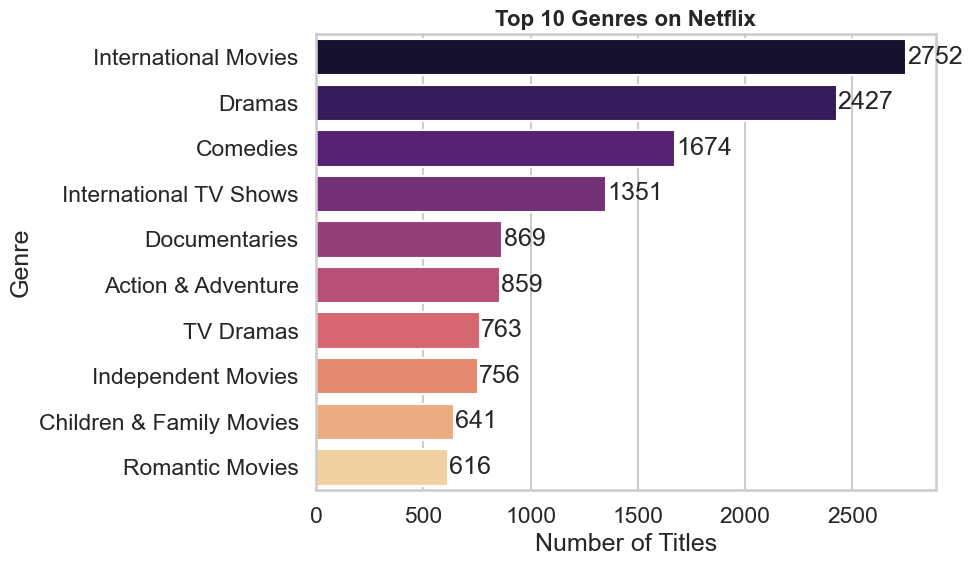

In [74]:
director_data = df.dropna(subset=["director"]).copy()
director_data["director"] = director_data["director"].str.split(", ")
director_exploded = director_data.explode("director")
top_directors = director_exploded["director"].value_counts().head(10)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    palette="magma",
    legend=False
)

plt.title("Top 10 Genres on Netflix", fontsize=16, weight="bold")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

for i, v in enumerate(top_genres.values):
    ax.text(v + 5, i, str(v), va="center")

plt.tight_layout()
plt.savefig(VISUALS_DIR / "top_genres.png", dpi=300)

plt.show()


##  Ratings
Most Netflix content falls under a few major ratings like TV-MA and TV-14.
This shows Netflix focuses heavily on mature and teen audiences rather than children-only content.

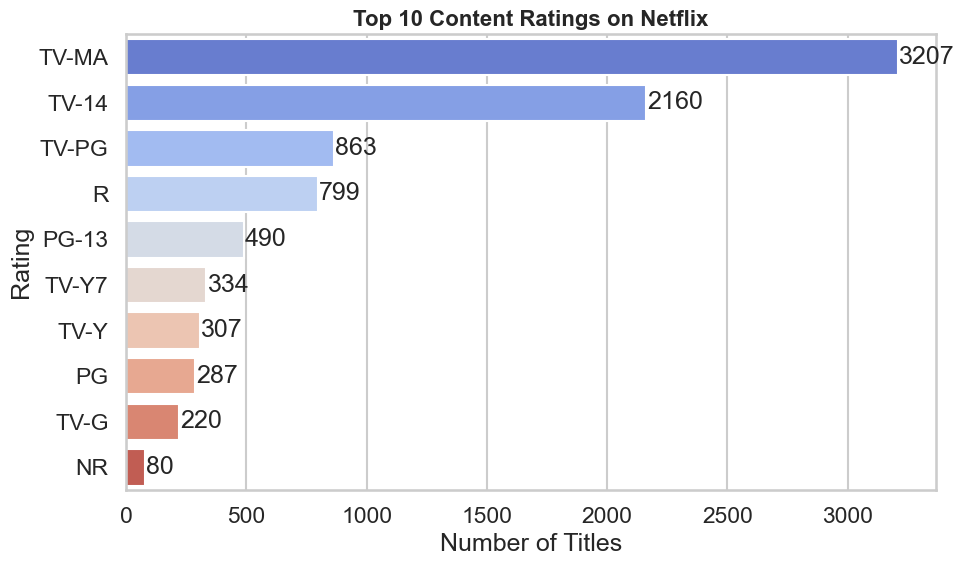

In [75]:
# Top Ratings on Netflix

rating_counts = df["rating"].value_counts().head(10)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index,
    hue=rating_counts.index,
    palette="coolwarm",
    legend=False
)

plt.title("Top 10 Content Ratings on Netflix", fontsize=16, weight="bold")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

for i, v in enumerate(rating_counts.values):
    ax.text(v + 5, i, str(v), va="center")

plt.tight_layout()
plt.savefig(VISUALS_DIR / "top_ratings.png", dpi=300)

plt.show()


## Top Directors

The visualization shows the directors who have produced the highest number of titles on Netflix.


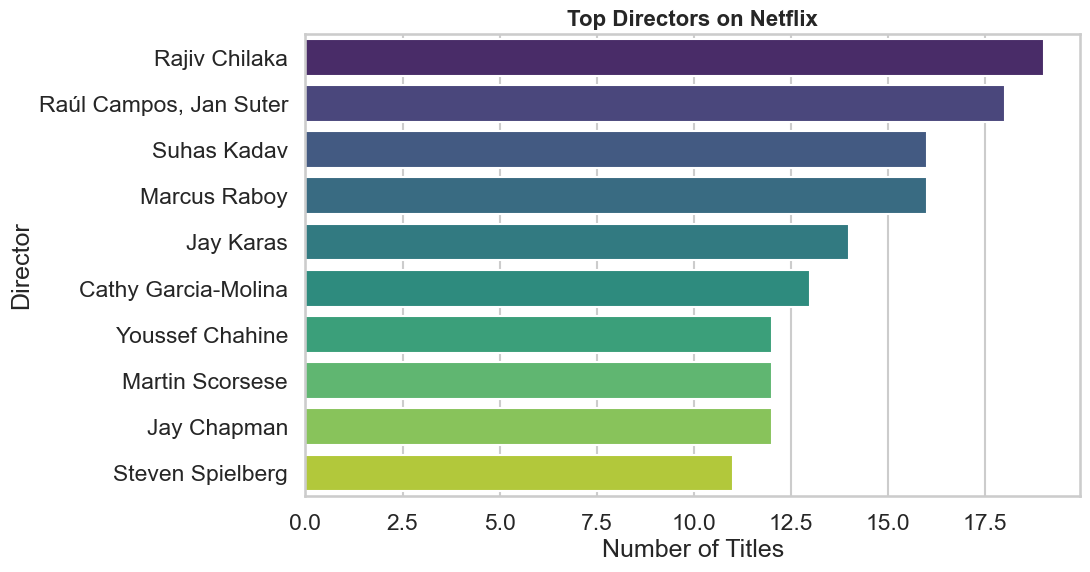

In [76]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    hue=top_directors.index,
    palette="viridis",
    legend=False
)

plt.title("Top Directors on Netflix", fontsize=16, weight="bold")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.savefig(VISUALS_DIR / "top_directors.png", dpi=300)

plt.show()